In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [4]:
pd.set_option('display.max_columns', 500)

In [2]:
path = "7. smartphones.csv"

## Data overview

In [5]:
df = pd.read_csv(path)

df.head()

,brand_name,model,price,avg_rating,5G_or_not,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,num_rear_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,resolution_height,resolution_width
0,apple,Apple iPhone 11,38999,7.3,0,bionic,6.0,2.65,3110.0,0,NaN,4,64,6.1,60,2,ios,12.0,12.0,0,1792,828
1,apple,Apple iPhone 11 (128GB),46999,7.5,0,bionic,6.0,2.65,3110.0,0,NaN,4,128,6.1,60,2,ios,12.0,12.0,0,1792,828
2,apple,Apple iPhone 11 Pro Max,109900,7.7,0,bionic,6.0,2.65,3500.0,1,18.0,4,64,6.5,60,3,ios,12.0,12.0,0,2688,1242
3,apple,Apple iPhone 12,51999,7.4,1,bionic,6.0,3.10,NaN,0,NaN,4,64,6.1,60,2,ios,12.0,12.0,0,2532,1170
4,apple,Apple iPhone 12 (128GB),55999,7.5,1,bionic,6.0,3.10,NaN,0,NaN,4,128,6.1,60,2,ios,12.0,12.0,0,2532,1170


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 980 non-null    object 
 1   model                      980 non-null    object 
 2   price                      980 non-null    int64  
 3   avg_rating                 879 non-null    float64
 4   5G_or_not                  980 non-null    int64  
 5   processor_brand            960 non-null    object 
 6   num_cores                  974 non-null    float64
 7   processor_speed            938 non-null    float64
 8   battery_capacity           969 non-null    float64
 9   fast_charging_available    980 non-null    int64  
 10  fast_charging              769 non-null    float64
 11  ram_capacity               980 non-null    int64  
 12  internal_memory            980 non-null    int64  
 13  screen_size                980 non-null    float64

In [7]:
df.describe(include='all')

,brand_name,model,price,avg_rating,5G_or_not,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,num_rear_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,resolution_height,resolution_width
count,980,980,980.000000,879.000000,980.000000,960,974.000000,938.000000,969.000000,980.000000,769.000000,980.000000,980.000000,980.000000,980.000000,980.000000,966,980.000000,975.000000,980.000000,980.000000,980.000000
unique,46,980,NaN,NaN,NaN,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN
top,xiaomi,Apple iPhone 11,NaN,NaN,NaN,snapdragon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,android,NaN,NaN,NaN,NaN,NaN
freq,134,1,NaN,NaN,NaN,413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,909,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,32520.504082,7.825825,0.560204,NaN,7.772074,2.427217,4817.748194,0.854082,46.126138,6.560204,141.036735,6.536765,92.256122,2.814286,NaN,50.319286,16.589744,0.630612,2214.663265,1075.852041
std,NaN,NaN,39531.812669,0.740285,0.496616,NaN,0.836845,0.464090,1009.540054,0.353205,34.277870,2.744378,107.134516,0.349162,28.988052,0.776441,NaN,33.000968,10.876944,0.482885,516.484254,290.164931
min,NaN,NaN,3499.000000,6.000000,0.000000,NaN,4.000000,1.200000,1821.000000,0.000000,10.000000,1.000000,8.000000,3.540000,60.000000,1.000000,NaN,2.000000,0.000000,0.000000,480.000000,480.000000
25%,NaN,NaN,12999.000000,7.400000,0.000000,NaN,8.000000,2.050000,4500.000000,1.000000,18.000000,4.000000,64.000000,6.500000,60.000000,2.000000,NaN,24.000000,8.000000,0.000000,1612.000000,1080.000000
50%,NaN,NaN,19994.500000,8.000000,1.000000,NaN,8.000000,2.300000,5000.000000,1.000000,33.000000,6.000000,128.000000,6.580000,90.000000,3.000000,NaN,50.000000,16.000000,1.000000,2400.000000,1080.000000
75%,NaN,NaN,35491.500000,8.400000,1.000000,NaN,8.000000,2.840000,5000.000000,1.000000,66.000000,8.000000,128.000000,6.670000,120.000000,3.000000,NaN,64.000000,16.000000,1.000000,2408.000000,1080.000000


## Cleaning the data

In [8]:
df.isna().sum()

brand_name                     0
model                          0
price                          0
avg_rating                   101
5G_or_not                      0
processor_brand               20
num_cores                      6
processor_speed               42
battery_capacity              11
fast_charging_available        0
fast_charging                211
ram_capacity                   0
internal_memory                0
screen_size                    0
refresh_rate                   0
num_rear_cameras               0
os                            14
primary_camera_rear            0
primary_camera_front           5
extended_memory_available      0
resolution_height              0
resolution_width               0
dtype: int64

In [16]:
#imputing with median and mean values for the missing numeric calues
df['avg_rating'] = df['avg_rating'].fillna(df['avg_rating'].mean())
df['battery_capacity'] = df['battery_capacity'].fillna(df['battery_capacity'].median())
df['processor_speed'] = df['processor_speed'].fillna(df['processor_speed'].median())
df['fast_charging'] = df['fast_charging'].fillna(df['fast_charging'].median())
df['primary_camera_front'] = df['primary_camera_front'].fillna(df['primary_camera_front'].median())

In [17]:
#for categorical column
#processor brand cannot be assumed to be of certain brand so we cannot impute by mode
#we will impute with 'unknown'
df['processor_brand'] = df['processor_brand'].fillna('unknown') 

#os can be imputed with mode
df['os'] = df['os'].fillna(df['os'].mode()[0])

In [18]:
df.isna().sum()

brand_name                   0
model                        0
price                        0
avg_rating                   0
5G_or_not                    0
processor_brand              0
num_cores                    6
processor_speed              0
battery_capacity             0
fast_charging_available      0
fast_charging                0
ram_capacity                 0
internal_memory              0
screen_size                  0
refresh_rate                 0
num_rear_cameras             0
os                           0
primary_camera_rear          0
primary_camera_front         0
extended_memory_available    0
resolution_height            0
resolution_width             0
dtype: int64

## Brand Overview

- Create a bar plot showing the distribution of smartphone brands in the
dataset.
- Identify the top 5 brands by count.


In [25]:
df['brand_name'].value_counts()



brand_name
xiaomi       134
samsung      132
vivo         111
realme        97
oppo          88
motorola      52
apple         46
oneplus       42
poco          41
tecno         33
iqoo          32
infinix       29
huawei        16
google        14
honor         13
nokia         13
itel          10
sony           9
asus           7
nubia          6
nothing        5
lava           4
jio            4
redmi          3
gionee         3
letv           3
lg             3
micromax       3
oukitel        3
ikall          3
royole         2
lyf            2
lenovo         2
doogee         2
zte            2
leitz          1
leeco          1
duoqin         1
sharp          1
cola           1
tcl            1
cat            1
tesla          1
vertu          1
blu            1
blackview      1
Name: count, dtype: int64

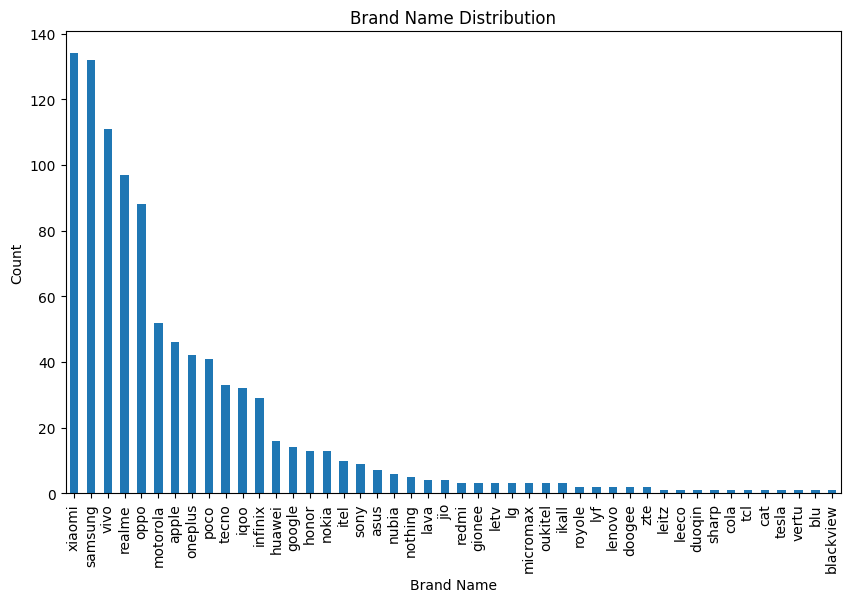

In [20]:
plt.figure(figsize=(10,6))
df['brand_name'].value_counts().plot(kind='bar')
plt.xlabel('Brand Name')
plt.ylabel('Count')
plt.title('Brand Name Distribution')
plt.show()

In [27]:
#top 5 brands
brand_count = df['brand_name'].value_counts().head(5).to_dict()
print("Top 5 brands:")
for key, value in brand_count.items():
    print(f'{key}: {value}')

Top 5 brands:
xiaomi: 134
samsung: 132
vivo: 111
realme: 97
oppo: 88


## Release Year Analysis

- Plot a line chart showing the trend of smartphone releases over the years.
- Identify the year with the highest number of smartphone releases.


In [28]:
print('No column related to release year present in the dataset')

No column related to release year present in the dataset


## Display Size Analysis

- Create a histogram to visualise the distribution of display sizes.
- Calculate the average display size for each brand and plot a bar chart

c:\Users\aarad\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


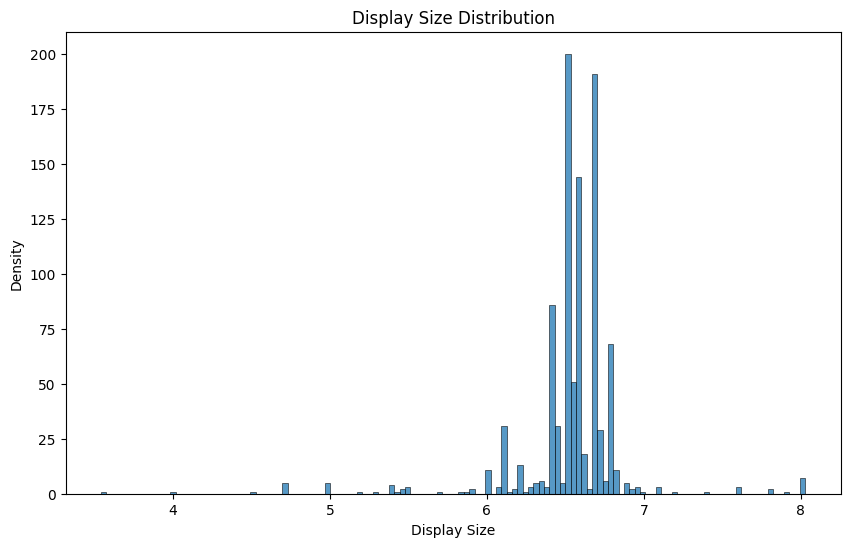

In [31]:
# display size is screen size in dataset
plt.figure(figsize=(10,6))
sns.histplot(df['screen_size'])
plt.xlabel('Display Size')
plt.ylabel('Density')
plt.title('Display Size Distribution')
plt.show()


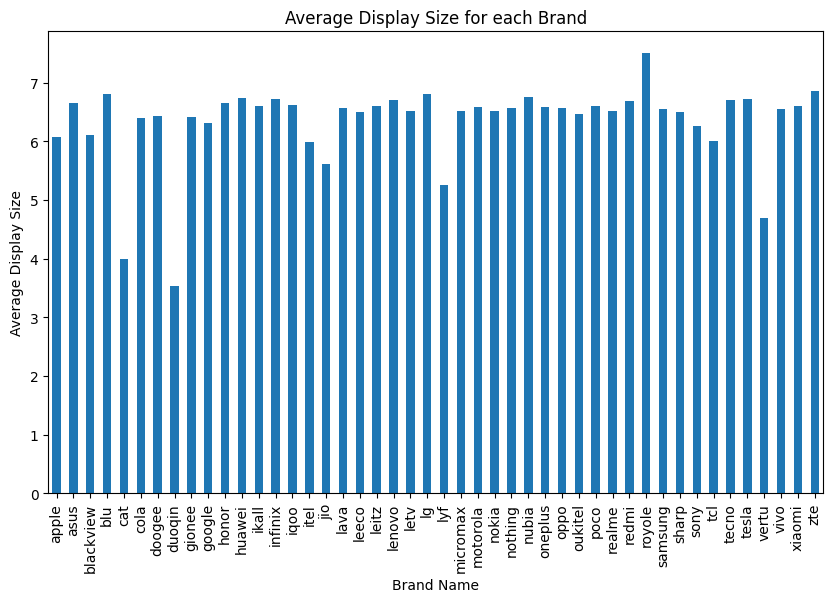

In [35]:
plt.figure(figsize=(10,6))
df.groupby('brand_name')['screen_size'].mean().plot(kind='bar')
plt.xlabel('Brand Name')
plt.ylabel('Average Display Size')
plt.title('Average Display Size for each Brand')
plt.show()
